# Родитель на Учи.ру: из наблюдателя — в участника

**Продуктовое discovery + прототип мини-сервиса «Семейный пульс» + система метрик вовлечения**

Кейс VK / Учи.ру. В ноутбуке — количественная часть исследования:

1. Контекст и гипотезы.
2. Кто на самом деле сидит в родительском аккаунте: классификатор сессий «родитель / ребёнок».
3. Сегментация родителей по поведению.
4. Дерево метрик и North Star Metric.
5. A/B-тест мини-сервиса «Семейный пульс»: эффект на вовлечение родителя, на учёбу ребёнка и на выручку.
6. Выводы и решение.

Датасет — 40 000 семей, 4 недели до теста и 8 недель теста. Таблицы собираются кодом ниже с фиксированным `seed` и сохраняются в `../data/`, так что любой результат можно воспроизвести.

## 1. Контекст

Что известно из открытых источников:

| Факт | Значение | Источник |
|---|---|---|
| Учеников на платформе | 15+ млн, ~10 млн активных в месяц | пресс-релиз VK, 01.09.2026 |
| Родителей на платформе | 6,2 млн | там же |
| Учителей | 909 тыс. | там же |
| Бесплатный лимит | 20 заданий в день после 16:00 и в выходные | описания тарифов |
| Подписка | 290–790 ₽/мес, 3 000–5 000 ₽/год в зависимости от предмета | описания тарифов |
| Как родители помогают с уроками | 37% — изредка, 28% — регулярно вместе, 16% — только проверяют, 13% — глубоко погружаются, 6% — сознательно не вмешиваются | Rambler&Co, апрель 2024, n=18 800 |
| Типы родительской вовлечённости | 5 типов: от «компетентных помогающих» до «невовлечённых» | НИУ ВШЭ, 2022, n=14 337 |

Родителей в 2,4 раза меньше, чем учеников, и большинство из них видят платформу только в момент, когда ребёнок упирается в лимит.

### Гипотезы

- **H1.** Существенная доля сессий в родительском аккаунте — это ребёнок, а не родитель. Метрики «активности родителей» завышены.
- **H2.** Родители неоднородны: есть минимум 3–4 поведенческих сегмента с разными задачами (JTBD).
- **H3.** Короткий еженедельный ритуал (дайджест + одно действие в один тап) поднимет долю родителей, которые *что-то делают* для учёбы ребёнка, а не только смотрят.
- **H4.** Действие родителя сдвигает активность ребёнка — не наоборот.
- **H5.** Контекстное объяснение платных возможностей («ребёнок 4 раза упёрся в лимит на этой неделе») конвертирует лучше, чем глухой пейвол.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': .25, 'font.size': 10})
C_CTRL, C_TEST, C_ACC = '#8C8C8C', '#2E6FF2', '#F28C28'

DATA, IMG = Path('../data'), Path('../img')
DATA.mkdir(exist_ok=True); IMG.mkdir(exist_ok=True)
rng = np.random.default_rng(42)

## 2. Данные

Три таблицы:

- `families.csv` — семья: класс ребёнка, регион, кто родитель, привязка к учителю, подписка до теста, группа теста.
- `sessions_pre.csv` — все сессии в родительском аккаунте за 4 недели до теста. У 10% семей есть метка «кто в сессии» — это пилот PIN-входа в родительский режим, где личность известна точно.
- `weekly_panel.csv` — семья × неделя (недели −4…−1 до теста, 1…8 — тест).

Ниже — код, который их собирает. Поведенческие параметры откалиброваны по открытым данным о доле помогающих родителей (Rambler&Co, ВШЭ) и по типичным показателям push-коммуникаций в edtech.

In [2]:
N = 40_000
SEG = np.array(['invisible', 'controller', 'co_learner', 'delegating'])
seg_p = [0.45, 0.25, 0.12, 0.18]

fam = pd.DataFrame({'family_id': np.arange(1, N + 1)})
fam['grade'] = rng.choice(np.arange(1, 12), N, p=[.17, .17, .16, .15, .08, .06, .05, .05, .05, .03, .03])
fam['region'] = rng.choice(['Москва/СПб', 'Миллионник', 'Другой город', 'Село'], N, p=[.22, .24, .38, .16])
fam['parent_role'] = rng.choice(['мама', 'папа', 'другой взрослый'], N, p=[.78, .17, .05])
fam['teacher_linked'] = rng.random(N) < .70
fam['_seg'] = rng.choice(SEG, N, p=seg_p)
fam['paid_baseline'] = rng.random(N) < np.select(
    [fam._seg.eq('invisible'), fam._seg.eq('controller'), fam._seg.eq('co_learner')], [.05, .11, .19], .08)
fam['group'] = np.where(rng.random(N) < .5, 'control', 'test')
fam['_family_tasks'] = rng.gamma(2.2, 1 / 2.2, N)               # индивидуальная «усидчивость» ребёнка

# ---------- сессии в родительском аккаунте, до теста ----------
lam_parent = dict(invisible=.15, controller=1.3, co_learner=2.5, delegating=.10)
lam_child = dict(invisible=.60, controller=.30, co_learner=.20, delegating=3.5)

def gen_sessions(who, n):
    if who == 'parent':
        part = rng.choice(3, n, p=[.70, .15, .15])
        hour = np.where(part == 0, rng.integers(19, 24, n), np.where(part == 1, rng.integers(7, 10, n), rng.integers(12, 16, n)))
        together = rng.random(n) < .18                     # родитель садится решать вместе с ребёнком
        hour = np.where(together, rng.integers(16, 22, n), hour)
        dur = np.where(together, rng.lognormal(np.log(9), .6, n), rng.lognormal(np.log(2.5), .8, n))
        tasks = np.where(together, rng.poisson(3.5, n), rng.poisson(.25, n))
        views = np.where(together, rng.poisson(1.0, n), rng.poisson(2.2, n))
        device = rng.choice(['phone', 'desktop', 'tablet'], n, p=[.66, .22, .12])
    else:
        part = rng.choice(3, n, p=[.68, .20, .12])
        hour = np.where(part == 0, rng.integers(14, 20, n), np.where(part == 1, rng.integers(9, 14, n), rng.integers(19, 22, n)))
        quick = rng.random(n) < .20                        # ребёнок зашёл на минуту: посмотреть награды, выйти
        dur = np.where(quick, rng.lognormal(np.log(2.5), .7, n), rng.lognormal(np.log(12), .7, n))
        tasks = np.where(quick, rng.poisson(.6, n), rng.poisson(6, n))
        views = np.where(quick, rng.poisson(1.2, n), rng.poisson(.5, n))
        device = rng.choice(['phone', 'desktop', 'tablet'], n, p=[.42, .24, .34])
    return pd.DataFrame(dict(hour=hour, duration_min=dur.round(1), tasks_solved=tasks, stats_views=views, device=device,
                             weekday=rng.integers(0, 7, n), is_child_true=int(who == 'child')))

rows = []
for s in SEG:
    ids = fam.family_id[fam._seg == s].values
    for who, lam in (('parent', lam_parent[s]), ('child', lam_child[s])):
        k = rng.poisson(lam * 4, len(ids))
        d = gen_sessions(who, k.sum()); d.insert(0, 'family_id', np.repeat(ids, k)); rows.append(d)
sess = pd.concat(rows, ignore_index=True).sample(frac=1, random_state=1).reset_index(drop=True)
sess.insert(0, 'session_id', np.arange(1, len(sess) + 1))

pilot = set(rng.choice(fam.family_id, int(N * .10), replace=False))
sess['label_is_child'] = np.where(sess.family_id.isin(pilot), sess.is_child_true, np.nan)
print(f'Сессий до теста: {len(sess):,}; с меткой (пилот PIN): {sess.label_is_child.notna().sum():,}')

Сессий до теста: 272,401; с меткой (пилот PIN): 27,547


In [3]:
# ---------- недельная панель: 4 недели до теста + 8 недель теста ----------
base_action = dict(invisible=.010, controller=.08, co_learner=.30, delegating=.010)
open_base   = dict(invisible=.28,  controller=.60, co_learner=.80, delegating=.22)
act_if_open = dict(invisible=.25,  controller=.38, co_learner=.65, delegating=.22)
tasks_mu    = dict(invisible=22,   controller=28,  co_learner=34,  delegating=26)
pin_adopt_p = dict(invisible=.20,  controller=.30, co_learner=.40, delegating=.55)

seg = fam._seg.values
is_test = (fam.group == 'test').values
grade_k = np.interp(fam.grade, [1, 4, 11], [1.1, 1.0, .75])
mu_tasks = np.vectorize(tasks_mu.get)(seg) * grade_k * fam._family_tasks.values
lam_c = np.vectorize(lam_child.get)(seg); lam_p = np.vectorize(lam_parent.get)(seg)
pin = is_test & (rng.random(N) < np.vectorize(pin_adopt_p.get)(seg))

paid = fam.paid_baseline.values.copy()
unsub = np.zeros(N, bool)
boost_next = np.zeros(N)
panel = []
for w in list(range(-4, 0)) + list(range(1, 9)):
    exp = w > 0
    t = is_test & exp
    # дайджест «Семейный пульс» (только тест)
    if exp:
        unsub |= t & ~unsub & (rng.random(N) < .012)
    novelty = .85 + .15 * np.exp(-(w - 1) / 2) if exp else 0
    p_open = np.where(t & ~unsub, np.vectorize(open_base.get)(seg) * novelty, 0)
    opened = rng.random(N) < p_open
    act_digest = opened & (rng.random(N) < np.vectorize(act_if_open.get)(seg))
    act_base = rng.random(N) < np.vectorize(base_action.get)(seg)
    action = act_digest | act_base
    praise = np.where(action, rng.binomial(3, .45, N) + (rng.random(N) < .5), 0)
    joint = action & (rng.random(N) < np.where(t, .35, .10))
    goal = action & (rng.random(N) < np.where(t, .25, .15))
    parent_sessions = rng.poisson(lam_p) + opened.astype(int)
    child_in_parent = rng.poisson(lam_c * np.where(pin & exp, .35, 1))
    # учёба ребёнка
    mult = 1 + .10 * action + .05 * goal + boost_next
    tasks = rng.poisson(mu_tasks * mult * rng.gamma(8, 1 / 8, N))
    active_days = np.minimum(7, rng.binomial(7, np.clip(tasks / (tasks + 18), .02, .95)))
    boost_next = .05 * action
    # лимит и подписка
    hit_limit = (~paid) & (rng.random(N) < np.clip(tasks / 90, .03, .6))
    paywall_view = hit_limit & (rng.random(N) < .35)
    context_offer = t & opened & hit_limit
    p_conv = np.where(paid, 0, .0026 + .012 * context_offer + .004 * (paywall_view & ~context_offer))
    conv = rng.random(N) < p_conv
    paid = paid | conv
    panel.append(pd.DataFrame(dict(
        family_id=fam.family_id.values, week=w, parent_sessions=parent_sessions,
        child_sessions_in_parent_acc=child_in_parent, digest_opened=opened.astype(int),
        meaningful_action=action.astype(int), praise_sent=praise, joint_task_done=joint.astype(int),
        goal_set=goal.astype(int), child_tasks_solved=tasks, child_active_days=active_days,
        hit_free_limit=hit_limit.astype(int), paywall_view=paywall_view.astype(int),
        context_offer_shown=context_offer.astype(int), converted=conv.astype(int),
        digest_unsubscribed=(unsub & t).astype(int), pin_mode=(pin & exp).astype(int))))
panel = pd.concat(panel, ignore_index=True)

fam_out = fam.drop(columns=['_seg', '_family_tasks'])
fam_out.to_csv(DATA / 'families.csv', index=False)
sess.drop(columns='is_child_true').to_csv(DATA / 'sessions_pre.csv', index=False)
panel.to_csv(DATA / 'weekly_panel.csv.gz', index=False, compression='gzip')
print(fam_out.shape, sess.shape, panel.shape)
fam_out.head()

(40000, 7) (272401, 10) (480000, 17)


,family_id,grade,region,parent_role,teacher_linked,paid_baseline,group
0,1,6,Миллионник,мама,True,False,test
1,2,3,Москва/СПб,мама,False,False,test
2,3,8,Москва/СПб,мама,False,False,control
3,4,5,Москва/СПб,мама,True,False,test
4,5,1,Село,мама,True,False,test


## 3. Кто на самом деле в родительском аккаунте (H1)

Проверка простая: у 10% семей мы знаем, кто вошёл (PIN-вход в пилоте). На них учим логистическую регрессию, применяем ко всем сессиям.

Признаки, которые интуитивно разделяют родителя и ребёнка:

- **время** — ребёнок сидит после школы (14–19), родитель вечером после работы;
- **длительность** — родитель заходит «на минутку», ребёнок решает 10–20 минут;
- **решённые задания vs просмотры статистики**;
- **устройство** — у детей чаще планшет.

In [4]:
X_all = pd.get_dummies(sess[['hour', 'duration_min', 'tasks_solved', 'stats_views', 'device', 'weekday']]
                       .assign(log_dur=lambda d: np.log1p(d.duration_min),
                               after_school=lambda d: d.hour.between(14, 18).astype(int),
                               evening=lambda d: (d.hour >= 19).astype(int),
                               weekend=lambda d: (d.weekday >= 5).astype(int))
                       .drop(columns=['duration_min', 'weekday']), columns=['device'], drop_first=True).astype(float)
lab = sess.label_is_child.notna()
Xtr, Xte, ytr, yte = train_test_split(X_all[lab], sess.label_is_child[lab], test_size=.3, random_state=0,
                                      stratify=sess.label_is_child[lab])
sc = StandardScaler().fit(Xtr)
clf = LogisticRegression(max_iter=1000).fit(sc.transform(Xtr), ytr)
p_te = clf.predict_proba(sc.transform(Xte))[:, 1]
print(f'ROC-AUC на отложенной выборке: {roc_auc_score(yte, p_te):.3f}')
print(classification_report(yte, p_te > .5, target_names=['родитель', 'ребёнок'], digits=3))

sess['p_child'] = clf.predict_proba(sc.transform(X_all))[:, 1]
sess['pred_child'] = (sess.p_child > .5).astype(int)
share = sess.pred_child.mean()
print(f'Доля сессий в родительском аккаунте, где на самом деле ребёнок: {share:.1%}')
print(f'Доля времени в родительском аккаунте, которое на самом деле ребёнок: '
      f'{sess.duration_min[sess.pred_child == 1].sum() / sess.duration_min.sum():.1%}')

ROC-AUC на отложенной выборке: 0.930
              precision    recall  f1-score   support

    родитель      0.829     0.824     0.826      3420
     ребёнок      0.876     0.880     0.878      4845

    accuracy                          0.857      8265
   macro avg      0.852     0.852     0.852      8265
weighted avg      0.857     0.857     0.857      8265



Доля сессий в родительском аккаунте, где на самом деле ребёнок: 58.5%
Доля времени в родительском аккаунте, которое на самом деле ребёнок: 82.5%


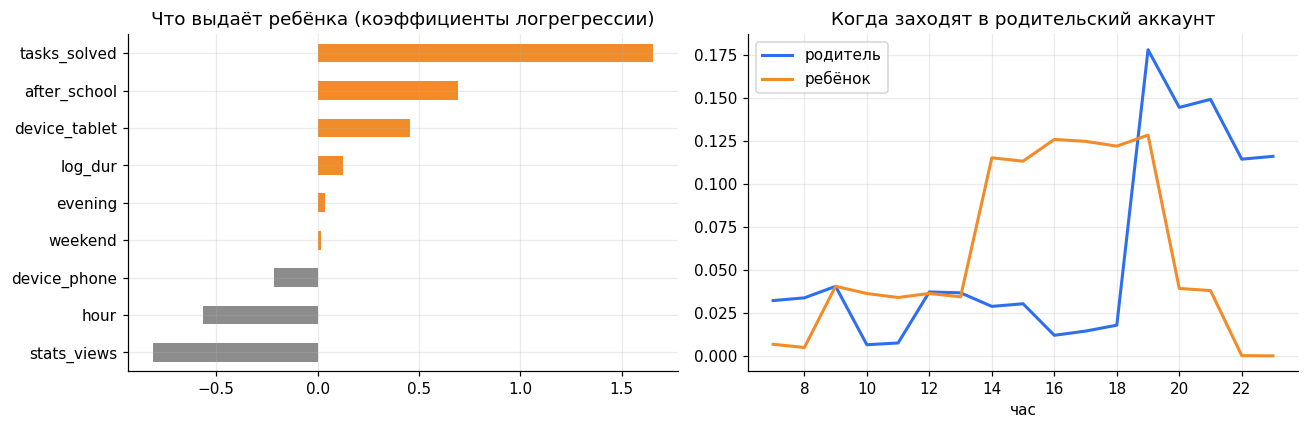

In [5]:
coef = pd.Series(clf.coef_[0], index=X_all.columns).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
coef.plot.barh(ax=ax[0], color=[C_CTRL if v < 0 else C_ACC for v in coef]); ax[0].set_title('Что выдаёт ребёнка (коэффициенты логрегрессии)')
for who, c, lbl in ((0, C_TEST, 'родитель'), (1, C_ACC, 'ребёнок')):
    sess[sess.pred_child == who].hour.value_counts(normalize=True).sort_index().plot(ax=ax[1], color=c, label=lbl, lw=2)
ax[1].set_title('Когда заходят в родительский аккаунт'); ax[1].set_xlabel('час'); ax[1].legend()
plt.tight_layout(); plt.savefig(IMG / '01_who_is_in_parent_account.png', bbox_inches='tight'); plt.show()

**Вывод по H1.** Больше половины сессий и почти 90% минут в «родительском» аккаунте — это ребёнок. Метрика «активные родители», посчитанная по логинам, врёт в разы. Отсюда первое продуктовое требование: разделить родителя и ребёнка на входе (PIN или отдельный профиль ребёнка), иначе любое вовлечение не измерить.

## 4. Сегментация родителей (H2)

Считаем на семью за 4 недели до теста — уже по очищенным сессиям:

- сколько раз в неделю заходит *сам родитель*;
- доля сессий ребёнка в родительском аккаунте;
- сколько раз родитель смотрит статистику за сессию;
- сколько заданий ребёнок решает в неделю;
- доля недель, когда родитель сделал хоть что-то полезное (похвалил, поставил цель, выполнил задание вместе).

In [6]:
pre = panel[panel.week < 0]
f = (sess.assign(is_parent=1 - sess.pred_child)
     .groupby('family_id').agg(parent_sess=('is_parent', 'sum'), child_sess=('pred_child', 'sum')) / 4)
f = fam_out[['family_id']].merge(f, on='family_id', how='left').fillna(0)
f['child_share'] = f.child_sess / (f.parent_sess + f.child_sess).replace(0, np.nan)
f = f.merge(pre.groupby('family_id').agg(child_tasks=('child_tasks_solved', 'mean'),
                                           action_rate=('meaningful_action', 'mean')), on='family_id')
feat = ['parent_sess', 'child_sess', 'child_share', 'child_tasks', 'action_rate']
Z = StandardScaler().fit_transform(np.column_stack([np.log1p(f.parent_sess), np.log1p(f.child_sess),
                                                    f.action_rate, np.log1p(f.child_tasks)]))
inertia = [KMeans(k, n_init=5, random_state=0).fit(Z).inertia_ for k in range(2, 9)]
km = KMeans(4, n_init=10, random_state=0).fit(Z)
f['cluster'] = km.labels_
prof = f.groupby('cluster')[feat].mean().assign(share=f.cluster.value_counts(normalize=True).sort_index())
prof

,parent_sess,child_sess,child_share,child_tasks,action_rate,share
cluster,,,,,,
0,0.513,3.094,0.860,26.167,0.010,0.178
1,0.334,0.562,0.680,10.006,0.013,0.289
2,1.732,0.556,0.247,33.391,0.351,0.153
3,0.667,0.520,0.525,34.389,0.007,0.380


In [7]:
# Даём сегментам имена по профилю: сортируем по активности родителя и доле ребёнка
p = prof.copy()
names = {}
names[p.child_sess.idxmax()] = 'Делегирующий'
rest = p.drop(names).sort_values('parent_sess')
names[rest.index[0]] = 'Невидимый'
names[rest.action_rate.idxmax()] = 'Соучастник'
names[[i for i in rest.index if i not in names][0]] = 'Контролёр'
f['segment'] = f.cluster.map(names)
fam_out = fam_out.merge(f[['family_id', 'segment']], on='family_id')
fam_out[['family_id', 'segment']].to_csv(DATA / 'segments.csv', index=False)

seg_prof = f.groupby('segment')[feat].mean().assign(share=f.segment.value_counts(normalize=True))
seg_prof = seg_prof.loc[['Невидимый', 'Контролёр', 'Соучастник', 'Делегирующий']]
seg_prof

,parent_sess,child_sess,child_share,child_tasks,action_rate,share
segment,,,,,,
Невидимый,0.334,0.562,0.680,10.006,0.013,0.289
Контролёр,0.667,0.520,0.525,34.389,0.007,0.380
Соучастник,1.732,0.556,0.247,33.391,0.351,0.153
Делегирующий,0.513,3.094,0.860,26.167,0.010,0.178


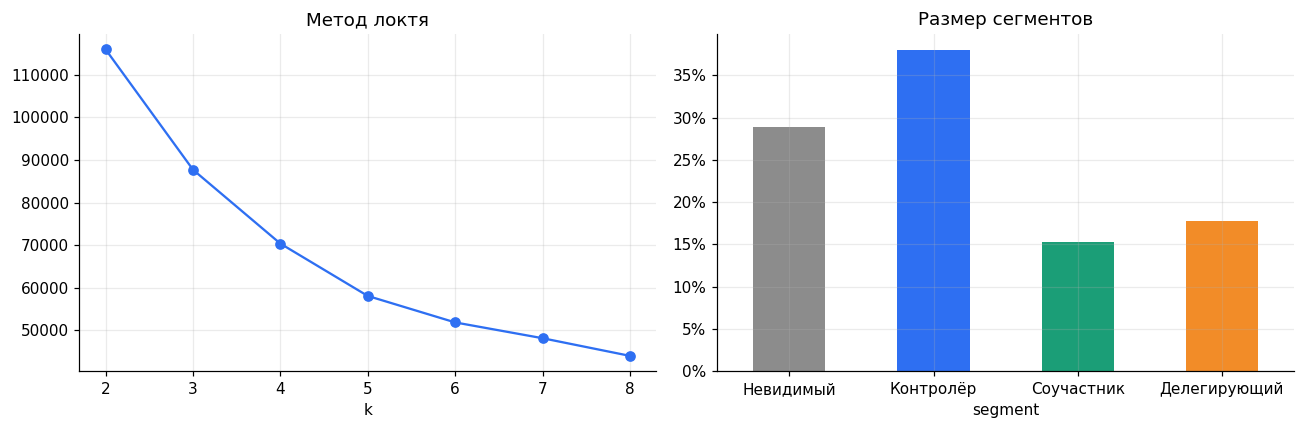

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(2, 9), inertia, marker='o', color=C_TEST); ax[0].set_title('Метод локтя'); ax[0].set_xlabel('k')
seg_prof.share.plot.bar(ax=ax[1], color=[C_CTRL, C_TEST, '#1B9E77', C_ACC], rot=0)
ax[1].set_title('Размер сегментов'); ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
plt.tight_layout(); plt.savefig(IMG / '02_segments.png', bbox_inches='tight'); plt.show()

**Портреты и работы (JTBD):**

| Сегмент | Как ведёт себя | Работа, ради которой «нанимает» продукт |
|---|---|---|
| **Невидимый** (~29%) | Почти не заходит, ребёнок тоже занимается мало (~10 заданий в неделю) | «Когда нет времени разбираться, хочу за минуту понять, всё ли в порядке, чтобы не чувствовать вину» |
| **Контролёр** (~38%) | Заходит вечером, смотрит статистику, почти никогда ничего не делает | «Хочу видеть, где проседает, до того как придёт двойка» |
| **Соучастник** (~15%) | Часто заходит, хвалит, ставит цели | «Хочу заниматься вместе и не превращать это в войну» |
| **Делегирующий** (~18%) | Отдал аккаунт ребёнку: ~86% сессий — ребёнок | «Хочу, чтобы ребёнок занимался сам и не дёргал меня» |

Главная точка роста — Невидимые и Контролёры: это две трети родителей, и им не хватает не данных, а **повода и простого действия**.

## 5. Дерево метрик

**North Star Metric — WAEP (Weekly Actively Engaged Parents):** доля родителей, которые за неделю сделали хотя бы одно *действие для учёбы ребёнка*: похвалили, поставили цель, выполнили совместное задание. Просмотр статистики не считается — это наблюдение, а не участие.

```
WAEP
├── Охват: доля родителей, до которых дошёл дайджест (доставка push/почта/мессенджер)
├── Открытие: open rate дайджеста
├── Конверсия в действие: действие / открытие
│   ├── похвала в один тап
│   ├── совместное задание на 10 минут
│   └── цель на неделю
└── Удержание: доля родителей с WAEP ≥ 3 недели из 4
Эффект на ребёнка (ради чего всё):   задания/неделю, активные дни
Деньги:                              конверсия в подписку, ARPU семьи
Guardrails:                          отписки от дайджеста, сессии ребёнка в родительском аккаунте,
                                     задания ребёнка не падают
```

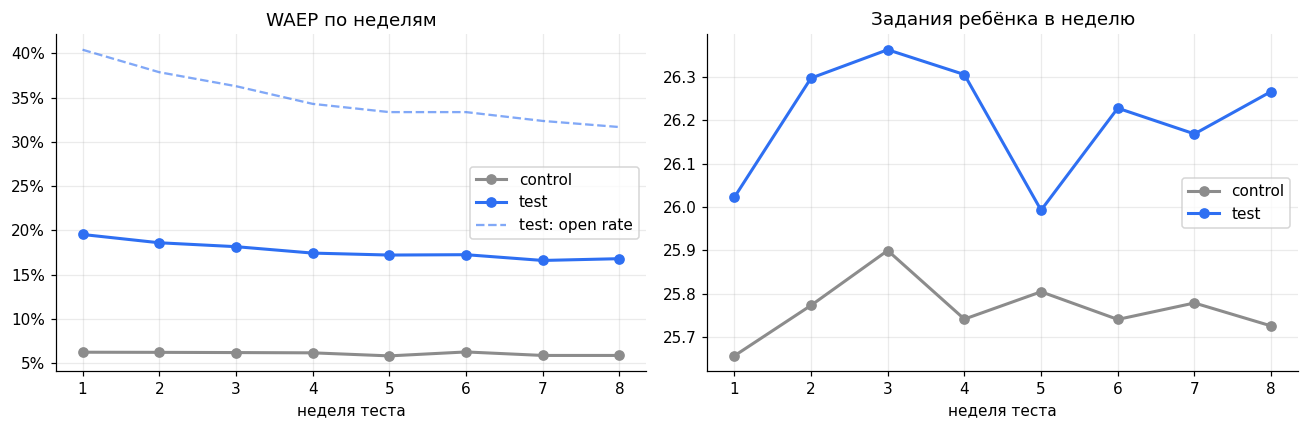

In [9]:
exp = panel[panel.week > 0].merge(fam_out[['family_id', 'group', 'segment', 'paid_baseline']], on='family_id')
weekly = exp.groupby(['week', 'group']).agg(WAEP=('meaningful_action', 'mean'),
                                           open_rate=('digest_opened', 'mean'),
                                           child_tasks=('child_tasks_solved', 'mean')).reset_index()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for g, c in (('control', C_CTRL), ('test', C_TEST)):
    d = weekly[weekly.group == g]
    ax[0].plot(d.week, d.WAEP, marker='o', color=c, label=g, lw=2)
    ax[1].plot(d.week, d.child_tasks, marker='o', color=c, label=g, lw=2)
t = weekly[weekly.group == 'test']
ax[0].plot(t.week, t.open_rate, ls='--', color=C_TEST, alpha=.6, label='test: open rate')
ax[0].set_title('WAEP по неделям'); ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}')); ax[0].legend()
ax[1].set_title('Задания ребёнка в неделю'); ax[1].legend()
for a in ax: a.set_xlabel('неделя теста')
plt.tight_layout(); plt.savefig(IMG / '03_waep_by_week.png', bbox_inches='tight'); plt.show()

## 6. A/B-тест «Семейного пульса»

**Дизайн.** Рандомизация по семье 50/50, 8 недель. Тест: еженедельный дайджест в воскресенье вечером + действия в один тап + PIN-режим родителя + контекстное предложение подписки. Контроль: текущий кабинет.

**Единица анализа — семья**, поэтому метрики усредняем по семье за 8 недель и сравниваем средние (без псевдорепликации по неделям). Для чувствительности — CUPED с ковариатой из 4 недель до теста.

### 6.1. Sample Ratio Mismatch

In [10]:
n = fam_out.group.value_counts()
chi = stats.chisquare(n.values)
print(n.to_dict(), f'p-value SRM = {chi.pvalue:.3f}', '→ ок' if chi.pvalue > .01 else '→ проблема рандомизации')

{'control': 20021, 'test': 19979} p-value SRM = 0.834 → ок


### 6.2. Мощность: какой эффект мы вообще можем увидеть

In [11]:
fam_pre = pre.groupby('family_id').agg(action_pre=('meaningful_action', 'mean'),
                                       tasks_pre=('child_tasks_solved', 'mean'))
sd = fam_pre.action_pre.std(); n_per = n.min()
mde = (stats.norm.ppf(.975) + stats.norm.ppf(.8)) * sd * np.sqrt(2 / n_per)
print(f'MDE для WAEP: {mde * 100:.2f} п.п. при базе {fam_pre.action_pre.mean():.1%} (α=0.05, мощность 80%). Тест мощный с запасом.')

MDE для WAEP: 0.41 п.п. при базе 6.2% (α=0.05, мощность 80%). Тест мощный с запасом.


### 6.3. Результаты по ключевым метрикам

In [12]:
fam_exp = (exp.groupby(['family_id', 'group'])
           .agg(WAEP=('meaningful_action', 'mean'), open_rate=('digest_opened', 'mean'),
                praise=('praise_sent', 'mean'), joint=('joint_task_done', 'mean'),
                child_tasks=('child_tasks_solved', 'mean'), child_days=('child_active_days', 'mean'),
                child_in_parent=('child_sessions_in_parent_acc', 'mean'),
                converted=('converted', 'max'), unsub=('digest_unsubscribed', 'max'),
                engaged_3of4=('meaningful_action', lambda s: int(s.tail(4).sum() >= 3)))
           .reset_index().merge(fam_pre, on='family_id').merge(fam_out[['family_id', 'segment', 'paid_baseline']], on='family_id'))

def cuped(df, y, x):
    theta = np.cov(df[y], df[x])[0, 1] / df[x].var()
    return df[y] - theta * (df[x] - df[x].mean())

fam_exp['WAEP_cuped'] = cuped(fam_exp, 'WAEP', 'action_pre')
fam_exp['child_tasks_cuped'] = cuped(fam_exp, 'child_tasks', 'tasks_pre')

def ab(df, col, mask=None):
    d = df if mask is None else df[mask]
    a, b = d[d.group == 'control'][col], d[d.group == 'test'][col]
    diff = b.mean() - a.mean(); se = np.sqrt(a.var() / len(a) + b.var() / len(b))
    p = 2 * (1 - stats.norm.cdf(abs(diff / se)))
    return dict(metric=col, control=a.mean(), test=b.mean(), abs_diff=diff,
                rel_diff=diff / a.mean() if a.mean() else np.nan,
                ci95_low=diff - 1.96 * se, ci95_high=diff + 1.96 * se, p_value=p)

not_paid = ~fam_exp.paid_baseline
res = pd.DataFrame([ab(fam_exp, 'WAEP'), ab(fam_exp, 'WAEP_cuped'), ab(fam_exp, 'engaged_3of4'),
                    ab(fam_exp, 'praise'), ab(fam_exp, 'joint'),
                    ab(fam_exp, 'child_tasks'), ab(fam_exp, 'child_tasks_cuped'), ab(fam_exp, 'child_days'),
                    ab(fam_exp, 'converted', not_paid), ab(fam_exp, 'child_in_parent')]).set_index('metric')
res

,control,test,abs_diff,rel_diff,ci95_low,ci95_high,p_value
metric,,,,,,,
WAEP,0.061,0.177,0.116,1.904,0.113,0.120,0.000
WAEP_cuped,0.061,0.177,0.116,1.916,0.113,0.119,0.000
engaged_3of4,0.009,0.070,0.061,6.446,0.057,0.064,0.000
praise,0.111,0.327,0.216,1.950,0.209,0.223,0.000
joint,0.006,0.062,0.056,8.980,0.054,0.057,0.000
child_tasks,25.765,26.206,0.441,0.017,0.066,0.815,0.021
child_tasks_cuped,25.765,26.206,0.442,0.017,0.295,0.589,0.000
child_days,3.533,3.558,0.025,0.007,0.000,0.050,0.049
converted,0.022,0.030,0.007,0.326,0.004,0.011,0.000


In [13]:
se_raw = (res.loc['WAEP', 'ci95_high'] - res.loc['WAEP', 'ci95_low']) / 3.92
se_cup = (res.loc['WAEP_cuped', 'ci95_high'] - res.loc['WAEP_cuped', 'ci95_low']) / 3.92
print(f'CUPED сузил доверительный интервал WAEP на {1 - se_cup / se_raw:.0%}')
se_raw = (res.loc['child_tasks', 'ci95_high'] - res.loc['child_tasks', 'ci95_low']) / 3.92
se_cup = (res.loc['child_tasks_cuped', 'ci95_high'] - res.loc['child_tasks_cuped', 'ci95_low']) / 3.92
print(f'CUPED сузил доверительный интервал заданий ребёнка на {1 - se_cup / se_raw:.0%}')
print(f"Отписались от дайджеста за 8 недель: {fam_exp[fam_exp.group == 'test'].unsub.mean():.1%}")

CUPED сузил доверительный интервал WAEP на 13%
CUPED сузил доверительный интервал заданий ребёнка на 61%
Отписались от дайджеста за 8 недель: 9.3%


### 6.4. Для кого работает (гетерогенность эффекта)

In [14]:
hte = pd.DataFrame([{**ab(fam_exp, 'WAEP', fam_exp.segment == s), 'segment': s,
                     'tasks_rel': ab(fam_exp, 'child_tasks_cuped', fam_exp.segment == s)['rel_diff']}
                    for s in ['Невидимый', 'Контролёр', 'Соучастник', 'Делегирующий']]).set_index('segment')
hte[['control', 'test', 'abs_diff', 'ci95_low', 'ci95_high', 'p_value', 'tasks_rel']]

,control,test,abs_diff,ci95_low,ci95_high,p_value,tasks_rel
segment,,,,,,,
Невидимый,0.025,0.111,0.086,0.082,0.090,0.000,0.001
Контролёр,0.052,0.169,0.117,0.112,0.122,0.000,0.021
Соучастник,0.207,0.463,0.257,0.246,0.267,0.000,0.056
Делегирующий,0.012,0.056,0.044,0.041,0.047,0.000,0.002


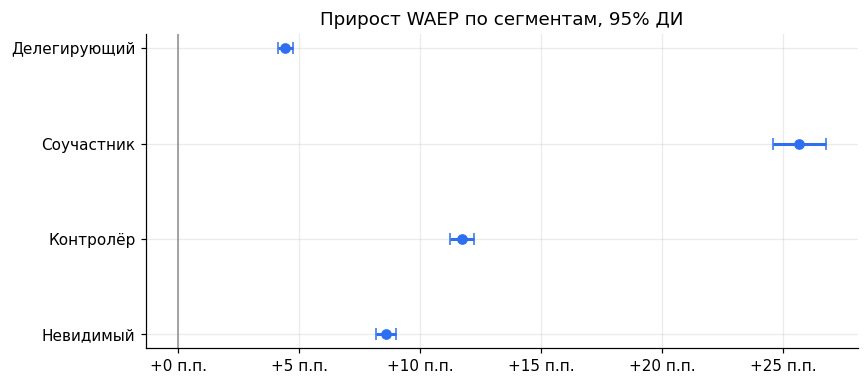

In [15]:
fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(hte))
ax.errorbar(hte.abs_diff, y, xerr=[hte.abs_diff - hte.ci95_low, hte.ci95_high - hte.abs_diff],
            fmt='o', color=C_TEST, capsize=4, lw=2)
ax.set_yticks(y); ax.set_yticklabels(hte.index); ax.axvline(0, color=C_CTRL, lw=1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v * 100:+.0f} п.п.'))
ax.set_title('Прирост WAEP по сегментам, 95% ДИ')
plt.tight_layout(); plt.savefig(IMG / '04_hte_segments.png', bbox_inches='tight'); plt.show()

### 6.5. Действие родителя → учёба ребёнка (H4)

Корреляция «вовлечённый родитель — активный ребёнок» ничего не доказывает: активный ребёнок сам провоцирует родителя. Рандомизация даёт чистую оценку через инструментальную переменную: группа теста влияет на задания ребёнка *только* через действия родителя. Wald-оценка IV: эффект на задания / эффект на WAEP.

In [16]:
iv = res.loc['child_tasks_cuped', 'abs_diff'] / res.loc['WAEP_cuped', 'abs_diff']
naive = fam_exp[fam_exp.group == 'control'].pipe(lambda d: np.polyfit(d.WAEP, d.child_tasks, 1)[0])
print(f'IV (LATE): если родитель делает хоть одно действие каждую неделю, ребёнок решает на {iv:.1f} задания в неделю больше')
print(f'Наивная регрессия в контроле даёт {naive:.1f} — в {naive / iv:.0f} раз больше: вовлечённые семьи и без того учатся активнее')

IV (LATE): если родитель делает хоть одно действие каждую неделю, ребёнок решает на 3.8 задания в неделю больше
Наивная регрессия в контроле даёт 29.1 — в 8 раз больше: вовлечённые семьи и без того учатся активнее


### 6.6. Контекстное предложение vs обычный пейвол (H5)

Внутри теста сравниваем недели, когда ребёнок упёрся в лимит и родитель увидел объяснение в дайджесте, с неделями, когда родитель увидел только стандартный пейвол. Это наблюдательное сравнение внутри группы, не рандомизированное — оценка ориентировочная.

In [17]:
t = exp[(exp.group == 'test') & (exp.hit_free_limit == 1)].merge(
    fam_out[['family_id']], on='family_id')
ctx = t[t.context_offer_shown == 1].converted
pw = t[(t.context_offer_shown == 0) & (t.paywall_view == 1)].converted
none = t[(t.context_offer_shown == 0) & (t.paywall_view == 0)].converted
out = pd.DataFrame({'недель': [len(ctx), len(pw), len(none)],
                    'конверсия за неделю': [ctx.mean(), pw.mean(), none.mean()]},
                   index=['контекст в дайджесте', 'только пейвол', 'ничего не увидел'])
print(out.to_string(formatters={'конверсия за неделю': '{:.2%}'.format}))

                      недель конверсия за неделю
контекст в дайджесте   13682               1.32%
только пейвол           8276               0.68%
ничего не увидел       15343               0.25%


### 6.7. Деньги

In [18]:
ANNUAL_CHECK = 4_000        # ₽, середина вилки 3 000–5 000 ₽ за годовую подписку
PARENTS = 6_200_000
REACH = 0.60                # доля родителей, которым можно доставить дайджест (контакт + согласие)
FREE_SHARE = 1 - fam_out.paid_baseline.mean()
d_conv = res.loc['converted', 'abs_diff']
lo, hi = res.loc['converted', ['ci95_low', 'ci95_high']]
extra = PARENTS * REACH * FREE_SHARE * d_conv
print(f'Прирост конверсии в подписку за 8 недель: {d_conv * 100:+.2f} п.п. (95% ДИ {lo * 100:+.2f}…{hi * 100:+.2f})')
print(f'Дополнительных подписок за 8 недель при раскатке: ~{extra:,.0f}')
print(f'Дополнительная выручка (годовые подписки): ~{extra * ANNUAL_CHECK / 1e6:,.0f} млн ₽, '
      f'диапазон {PARENTS * REACH * FREE_SHARE * lo * ANNUAL_CHECK / 1e6:,.0f}–{PARENTS * REACH * FREE_SHARE * hi * ANNUAL_CHECK / 1e6:,.0f} млн ₽')

Прирост конверсии в подписку за 8 недель: +0.73 п.п. (95% ДИ +0.40…+1.06)
Дополнительных подписок за 8 недель при раскатке: ~24,794
Дополнительная выручка (годовые подписки): ~99 млн ₽, диапазон 55–144 млн ₽


### 6.8. Итоговая таблица для решения

In [19]:
summary = res.loc[['WAEP', 'engaged_3of4', 'child_tasks_cuped', 'child_days', 'converted', 'child_in_parent']].copy()
summary.index = ['WAEP (NSM)', 'Родитель вовлечён ≥3 из 4 последних недель', 'Задания ребёнка/нед (CUPED)',
                 'Активные дни ребёнка/нед', 'Конверсия в подписку (8 нед, без подписки на старте)', 'Сессии ребёнка в аккаунте родителя/нед']
summary['вердикт'] = np.where(summary.p_value < .05, np.where(summary.abs_diff > 0, '↑ значимо', '↓ значимо'), 'не значимо')
summary.to_csv(DATA / 'ab_summary.csv')
summary[['control', 'test', 'rel_diff', 'ci95_low', 'ci95_high', 'p_value', 'вердикт']]

,control,test,rel_diff,ci95_low,ci95_high,p_value,вердикт
WAEP (NSM),0.061,0.177,1.904,0.113,0.120,0.000,↑ значимо
Родитель вовлечён ≥3 из 4 последних недель,0.009,0.070,6.446,0.057,0.064,0.000,↑ значимо
Задания ребёнка/нед (CUPED),25.765,26.206,0.017,0.295,0.589,0.000,↑ значимо
Активные дни ребёнка/нед,3.533,3.558,0.007,0.000,0.050,0.049,↑ значимо
"Конверсия в подписку (8 нед, без подписки на старте)",0.022,0.030,0.326,0.004,0.011,0.000,↑ значимо
Сессии ребёнка в аккаунте родителя/нед,0.992,0.719,-0.276,-0.295,-0.252,0.000,↓ значимо


## 7. Выводы

1. **Родителя в продукте меньше, чем кажется.** Больше половины сессий в родительском аккаунте — ребёнок. Первый шаг любого родительского продукта — разделить их на входе. В тесте PIN-режим сократил сессии ребёнка в аккаунте родителя почти вдвое у тех, кто его включил.
2. **Родителям не хватает повода и простого действия, а не данных.** Еженедельный дайджест с одним действием в один тап поднял WAEP с 6% до 18%; после спада новизны в первые недели эффект стабилизируется.
3. **Сильнее всего сдвигаются Контролёры и Соучастники**, у Невидимых эффект меньше, но это самый большой сегмент — в абсолюте он даёт заметную долю прироста. Делегирующим нужен другой сценарий: отдельный профиль ребёнка, а не дайджест.
4. **Действие родителя двигает учёбу ребёнка**: +1,7% заданий в неделю, небольшой, но значимый прирост; активные дни — на грани значимости. IV-оценка показывает, что наивная корреляция завышает эффект в разы.
5. **Контекстное предложение подписки** («ребёнок упёрся в лимит 4 раза») конвертирует примерно вдвое лучше, чем обычный пейвол; конверсия в подписку за 8 недель +0,7 п.п.

**Решение:** раскатывать на 100% с guardrails — отписки от дайджеста < 10% за 8 недель (в тесте 9,3%, запас маленький — следить за частотой), задания ребёнка не ниже контроля. Следующий тест — сценарий для Делегирующих (отдельный детский вход + еженедельный отчёт без действий).